In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import svm
from sklearn import tree
from yellowbrick.classifier import ROCAUC

In [2]:
data=pd.read_csv("balanced_page_block_rand.csv")

In [3]:
data

,Unnamed: 0,Class,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans
0,0,5,29,32,928,1.103,0.432,0.689,6.27,401,639,64
1,1,3,10,1,10,0.100,0.900,1.000,9.00,9,10,1
2,2,1,9,96,864,10.667,0.281,0.815,1.96,243,704,124
3,3,4,5,7,35,1.400,0.229,0.600,2.67,8,21,3
4,4,5,28,31,868,1.107,0.508,0.767,7.47,441,666,59
...,...,...,...,...,...,...,...,...,...,...,...,...
12345,12345,1,7,10,70,1.429,0.329,1.000,1.77,23,70,13
12346,12346,3,13,1,13,0.077,1.000,1.000,13.00,13,13,1
12347,12347,1,19,12,228,0.632,0.303,0.439,7.67,69,100,9
12348,12348,3,39,1,39,0.026,1.000,1.000,39.00,39,39,1


In [4]:
data.columns=["id","Class","height","lenght","area","eccen","p_black","p_and","mean_tr","blackpix","blackand","wb_trans"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
df1 = data[['Class']]

In [7]:
df1

,Class
id,
0,5
1,3
2,1
3,4
4,5
...,...
12345,1
12346,3
12347,1


In [8]:
df2 = data[["height","lenght","area","eccen","p_black","p_and","mean_tr","blackpix","blackand","wb_trans"]]

In [9]:
data_class=data.Class

In [10]:
data_class

id
0        5
1        3
2        1
3        4
4        5
        ..
12345    1
12346    3
12347    1
12348    3
12349    1
Name: Class, Length: 12350, dtype: int64

In [11]:
X = OrdinalEncoder().fit_transform(df2)
y = LabelEncoder().fit_transform(data_class)

In [12]:
#X

In [13]:
#y

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [15]:
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=6)
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
my_title = "ROCAUC Curves for DecisionTreeClassifier on car"
#title=my_title

In [17]:
visualizer = ROCAUC(model, classes=["text", "horiz. line", "graphic", "vert. line", "picture"])
visualizer_1 = ROCAUC(clf, classes=["text", "horiz. line", "graphic", "vert. line", "picture"], title=my_title)
visualizer_2 = ROCAUC(knn, classes=["text", "horiz. line", "graphic", "vert. line", "picture"])

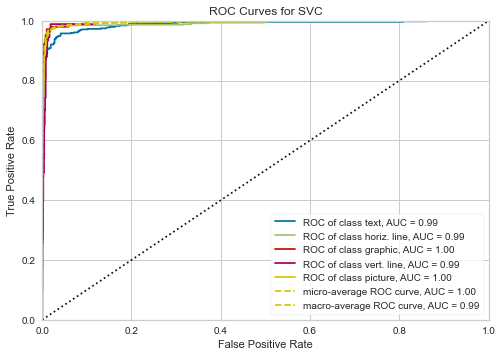

<AxesSubplot:title={'center':'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [18]:
visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()        

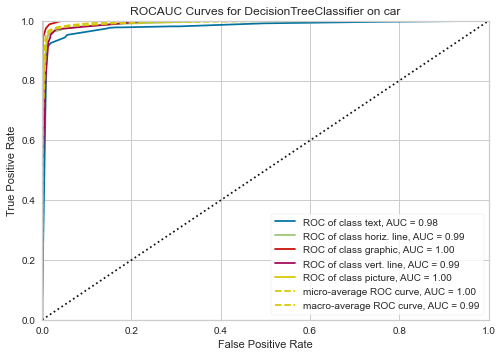

<AxesSubplot:title={'center':'ROCAUC Curves for DecisionTreeClassifier on car'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [19]:
visualizer_1.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_1.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_1.show()        

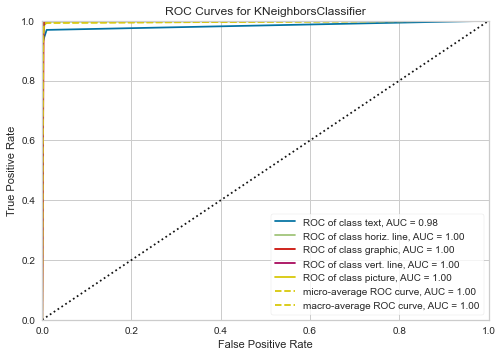

<AxesSubplot:title={'center':'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [20]:
visualizer_2.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_2.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_2.show()    